# Lens Picture

This notebook demonstrates the simulation and optimization of an optical system using the `diffinytrace` package.  
It was run in **Google Colab** to take advantage of GPU acceleration and Google Drive integration for saving results.


In [1]:
%pip install diffinytrace.zip

Processing ./diffinytrace.zip
  Preparing metadata (setup.py) ... done
  Created wheel for diffinytrace: filename=diffinytrace-2.1-py3-none-any.whl size=80306 sha256=2add9804e093405864b6aeb2ae150d4f45399d204f268e1be8b55a9ba25bc436
  Stored in directory: /tmp/pip-ephem-wheel-cache-2npyhl5t/wheels/70/69/4f/ea4fe5be2f8364573c110f26b2b32d6dd0dd84ab84341234f7
Successfully built diffinytrace
  Attempting uninstall: diffinytrace
    Found existing installation: diffinytrace 2.1
    Uninstalling diffinytrace-2.1:
      Successfully uninstalled diffinytrace-2.1


In [2]:
from google.colab import drive
drive.mount('/content/gdrive')
from os import listdir
from os.path import isfile, join
path = "gdrive/MyDrive/results_final"


Mounted at /content/gdrive


num of conv points should probably be at least  336.0


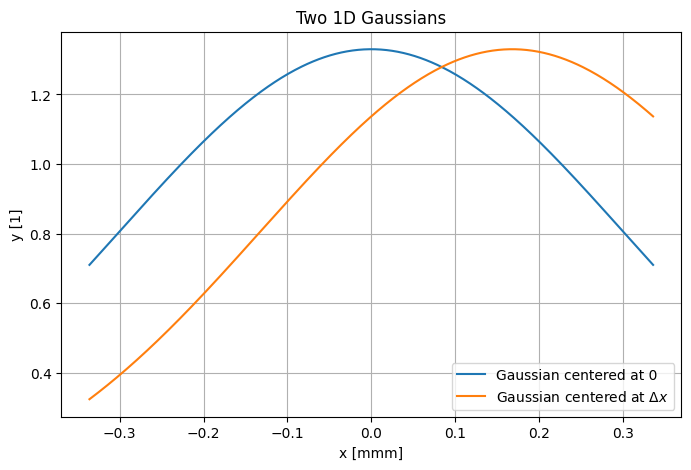

/usr/local/lib/python3.11/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


BEGIN: opti after refine: coeff shape: torch.Size([4, 4])
last_merit tensor(0.0085, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00853656141575
last_error tensor(0.0087) 0.008677773515639016
END
BEGIN: opti after refine: coeff shape: torch.Size([6, 6])
last_merit tensor(0.0077, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00774111153222
last_error tensor(0.0079) 0.00787440368701151
END
BEGIN: opti after refine: coeff shape: torch.Size([10, 10])
last_merit tensor(0.0063, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00625242828563
last_error tensor(0.0064) 0.006426652380144257
END
BEGIN: opti after refine: coeff shape: torch.Size([18, 18])
last_merit tensor(0.0051, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00509004906742
last_error tensor(0.0053) 0.005279878354053733
END
BEGIN: opti after refine: coeff shape: torch.Size([34, 34])
last_merit tensor(0.0042, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00418895219319
last_error tensor(0.0048) 0.004824928753015299
END
BEGIN: opti after refine:

100%|██████████| 1000/1000 [16:19<00:00,  1.02it/s]


Data saved to gdrive/MyDrive/results_final/lens_picture//results_classical/results_dict.pkl
BEGIN: opti after refine: coeff shape: torch.Size([4, 4])
last_merit tensor(0.0074, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00740173366279
last_error tensor(0.0087) 0.008673193372711155
END
BEGIN: opti after refine: coeff shape: torch.Size([6, 6])
last_merit tensor(0.0065, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00650772501314
last_error tensor(0.0079) 0.007875645338847307
END
BEGIN: opti after refine: coeff shape: torch.Size([10, 10])
last_merit tensor(0.0047, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00473633132184
last_error tensor(0.0064) 0.006433483613985187
END
BEGIN: opti after refine: coeff shape: torch.Size([18, 18])
last_merit tensor(0.0032, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00320672328347
last_error tensor(0.0053) 0.005298951138324223
END
BEGIN: opti after refine: coeff shape: torch.Size([34, 34])
last_merit tensor(0.0020, device='cuda:0', grad_fn=<SqrtBackward0>) 

100%|██████████| 1000/1000 [16:18<00:00,  1.02it/s]


Data saved to gdrive/MyDrive/results_final/lens_picture//results_desired_irr_smoothing/results_dict.pkl


In [3]:
#%%
import diffinytrace as dit
from sunlight_picture import create_lens
import os
import pickle
import gc

def save_data(data, filename):
    with open(filename, 'wb') as file:
        pickle.dump(data, file)
    print(f"Data saved to {filename}")

def load_data(filename):
    with open(filename, 'rb') as file:
        data = pickle.load(file)
    print(f"Data loaded from {filename}")
    return data

def create_folder(folder_path):
    try:
        os.makedirs(folder_path, exist_ok=True)
        return f"Folder created successfully at: {folder_path}" if not os.path.exists(folder_path) else f"Folder already exists at: {folder_path}"
    except Exception as e:
        return f"An error occurred: {e}"

device = "cuda:0"
image_file_name = "img1.jpg"
results_folder_main = path+"/lens_picture/"
create_folder(results_folder_main)
sigma_final = 0.3

sigmas = None
ns_start = [4,4]
orders = [3,3]
num_refinements = 6

aperture_radius_source = 21.
image_padding = 0.2
grid_size = 300
num_rays = 2**20
#[1601,1601]
from diffinytrace import utils
#from diffinytrace.nonimaging import smoothing
aperture_radius_detector = aperture_radius_source*(1+image_padding)

print("num of conv points should probably be at least ", 2.0*aperture_radius_detector*2.0/sigma_final)

import numpy as np
import matplotlib.pyplot as plt

# Parameters
dx = (aperture_radius_detector*2.0)/grid_size
x = np.linspace(-dx*2, dx*2, 500)  # x-axis range

# Gaussian 1 centered at 0
gaussian1 = (1 / (sigma_final * np.sqrt(2 * np.pi))) * np.exp(-x**2 / (2 * sigma_final**2))

# Gaussian 2 centered at dx
gaussian2 = (1 / (sigma_final * np.sqrt(2 * np.pi))) * np.exp(-(x - dx)**2 / (2 * sigma_final**2))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, gaussian1, label='Gaussian centered at 0')
plt.plot(x, gaussian2, label=f'Gaussian centered at $\Delta x$')
plt.title("Two 1D Gaussians")
plt.xlabel("x [mmm]")
plt.ylabel("y [1]")
plt.legend()
plt.grid()
plt.show()

gc.collect()
irr_func = utils.irradiance_importer.create_irradiance_from_image_square(image_file_name,image_padding,0.,aperture_radius_detector)

#quantity2D.plot(final_smoother.desired_smooth_irradiance.cpu().detach().numpy(),"Smoothed Desired Irr.",aperture_radius_detector,cmap="gray")
#plt.imshow(final_smoother.desired_smooth_irradiance.cpu().detach().numpy()[::-1])
#%%
def make_run(subfolder_main,use_desired_irradiance_smoothing):
    create_folder(subfolder_main)
    subfolder = subfolder_main

    #create_folder(subfolder)
    kwargs = dict(image_file_name=image_file_name,
                lens_material=dit.materials["PMMA"],
                air_material=dit.materials["NONE"],
                device=device,
                sigma=sigma_final,
                use_desired_irradiance_smoothing=use_desired_irradiance_smoothing,
                num_rays=num_rays,
                num_refinements=num_refinements,
                grid_size=grid_size)

    results = create_lens(**kwargs)
    save_data(results, subfolder+"/results_dict.pkl")
    del results
    gc.collect()

def run_all_methods():


    gc.collect()
    subfolder_main = results_folder_main+"/results_classical"
    make_run(subfolder_main,use_desired_irradiance_smoothing = False)

    gc.collect()

    subfolder_main = results_folder_main+"/results_desired_irr_smoothing"
    make_run(subfolder_main,use_desired_irradiance_smoothing = True)

    gc.collect()


run_all_methods()


In [ ]:
#import os
#os.kill(os.getpid(), 9)